# ML-Based Return Forecasting

Using XGBoost to predict short-term stock returns based on engineered features
(momentum, moving averages, volatility), as an improvement over naive historical-average
return estimates used in classical Markowitz optimization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the same price data
df = pd.read_csv('../data/raw_prices.csv', header=[0, 1], index_col=0, parse_dates=True)
close_prices = df['Close']
close_prices.head()

Ticker,AAPL,AMZN,GOOGL,MSFT,TSLA
Date,,,,,
2019-01-02,37.469204,76.956497,52.270508,94.193138,20.674667
2019-01-03,33.736996,75.014000,50.822842,90.727959,20.024000
2019-01-04,35.177208,78.769501,53.429718,94.947639,21.179333
2019-01-07,35.098907,81.475502,53.323177,95.068748,22.330667
2019-01-08,35.768009,82.829002,53.791519,95.758072,22.356667


## Feature Engineering (AAPL)

Creating lagged returns, moving averages, rolling volatility, and momentum features
to use as inputs for the XGBoost model.

In [2]:
# Work with AAPL first
aapl = close_prices[['AAPL']].copy()
aapl.columns = ['price']

# Daily return (what we had before, just for this one stock)
aapl['return'] = aapl['price'].pct_change()

# Lagged returns — yesterday's, 2 days ago's, etc.
aapl['lag_1'] = aapl['return'].shift(1)
aapl['lag_2'] = aapl['return'].shift(2)
aapl['lag_3'] = aapl['return'].shift(3)
aapl['lag_5'] = aapl['return'].shift(5)

# Moving averages of price
aapl['ma_10'] = aapl['price'].rolling(window=10).mean()
aapl['ma_50'] = aapl['price'].rolling(window=50).mean()

# Rolling volatility (10-day standard deviation of returns)
aapl['volatility_10'] = aapl['return'].rolling(window=10).std()

# Momentum: % change over the last 10 days
aapl['momentum_10'] = aapl['price'].pct_change(periods=10)

aapl.head(15)

,price,return,lag_1,lag_2,lag_3,lag_5,ma_10,ma_50,volatility_10,momentum_10
Date,,,,,,,,,,
2019-01-02,37.469204,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-03,33.736996,-0.099607,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-04,35.177208,0.042689,-0.099607,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-07,35.098907,-0.002226,0.042689,-0.099607,NaN,NaN,NaN,NaN,NaN,NaN
2019-01-08,35.768009,0.019063,-0.002226,0.042689,-0.099607,NaN,NaN,NaN,NaN,NaN
2019-01-09,36.375401,0.016981,0.019063,-0.002226,0.042689,NaN,NaN,NaN,NaN,NaN
2019-01-10,36.491657,0.003196,0.016981,0.019063,-0.002226,-0.099607,NaN,NaN,NaN,NaN
2019-01-11,36.133385,-0.009818,0.003196,0.016981,0.019063,0.042689,NaN,NaN,NaN,NaN
2019-01-14,35.590046,-0.015037,-0.009818,0.003196,0.016981,-0.002226,NaN,NaN,NaN,NaN


## Define Target Variable and Clean Data

The target is next-day return (shifted forward), so the model learns to predict the future
using only past/current information. Rows with missing values (from rolling windows) are dropped.

In [3]:
# Target: NEXT day's return (shift -1 moves tomorrow's value onto today's row)
aapl['target'] = aapl['return'].shift(-1)

# Drop rows with any missing values (early rows without full rolling history,
# and the very last row, which has no "tomorrow" to predict)
aapl_clean = aapl.dropna()

print(f"Original rows: {len(aapl)}")
print(f"Rows after cleaning: {len(aapl_clean)}")
aapl_clean.head()

Original rows: 1510
Rows after cleaning: 1460


,price,return,lag_1,lag_2,lag_3,lag_5,ma_10,ma_50,volatility_10,momentum_10,target
Date,,,,,,,,,,,
2019-03-14,43.780022,0.011116,0.004422,0.011235,0.034642,-0.011575,42.212830,39.337754,0.012557,0.061103,0.013008
2019-03-15,44.349533,0.013008,0.011116,0.004422,0.011235,0.002377,42.478517,39.475361,0.012680,0.063725,0.010208
2019-03-18,44.802265,0.010208,0.013008,0.011116,0.004422,0.034642,42.768509,39.696666,0.012730,0.069207,-0.007925
2019-03-19,44.447227,-0.007925,0.010208,0.013008,0.011116,0.011235,43.030621,39.882066,0.013321,0.062667,0.008739
2019-03-20,44.835636,0.008739,-0.007925,0.010208,0.013008,0.004422,43.355642,40.076801,0.012650,0.078158,0.036830


## Train/Test Split (Chronological)

Unlike typical ML datasets, time-series data must be split chronologically — NOT randomly —
to avoid the model "seeing the future" during training. We train on the earlier ~80% of dates
and test on the most recent ~20%, simulating real-world deployment.

In [6]:
# Separate features (X) from target (y)
feature_cols = ['lag_1', 'lag_2', 'lag_3', 'lag_5', 'ma_10', 'ma_50', 'volatility_10', 'momentum_10']

X = aapl_clean[feature_cols]
y = aapl_clean['target']

# Chronological split — 80% earliest dates for training, 20% most recent for testing
split_index = int(len(aapl_clean) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f"Training set: {len(X_train)} rows, from {X_train.index.min()} to {X_train.index.max()}")
print(f"Test set: {len(X_test)} rows, from {X_test.index.min()} to {X_test.index.max()}")

Training set: 1168 rows, from 2019-03-14 00:00:00 to 2023-10-31 00:00:00
Test set: 292 rows, from 2023-11-01 00:00:00 to 2024-12-30 00:00:00


## Train the XGBoost Model

Training an XGBoost regressor on the training set (2019–2023) to predict next-day returns,
then generating predictions on the unseen test set (Nov 2023–Dec 2024).


In [7]:
import xgboost as xgb

# Create the model
# n_estimators = number of decision trees to build
# max_depth = how complex each tree can get (deeper = more detail, but risk of overfitting)
# learning_rate = how much each tree corrects the previous ones' mistakes (smaller = more cautious learning)
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)

# Train it on the training data
model.fit(X_train, y_train)

print("Model trained successfully.")

Model trained successfully.


## Evaluate Model Performance

Comparing predicted vs actual returns on the test set using error metrics and directional
accuracy, and benchmarking against a naive baseline (predicting the historical average return).

In [8]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Generate predictions on the test set (data the model has never seen)
y_pred = model.predict(X_test)

# Error metrics
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)

# Directional accuracy: did we correctly predict up vs down?
direction_actual = np.sign(y_test)
direction_pred = np.sign(y_pred)
directional_accuracy = (direction_actual == direction_pred).mean()

# Naive baseline: just predict the average training return every single day
naive_pred = np.full_like(y_test, y_train.mean())
naive_rmse = np.sqrt(mean_squared_error(y_test, naive_pred))

print(f"XGBoost RMSE: {rmse:.5f}")
print(f"Naive Baseline RMSE: {naive_rmse:.5f}")
print(f"XGBoost MAE: {mae:.5f}")
print(f"Directional Accuracy: {directional_accuracy:.2%}")

XGBoost RMSE: 0.01445
Naive Baseline RMSE: 0.01368
XGBoost MAE: 0.01092
Directional Accuracy: 46.92%


## Visualize Predicted vs Actual Returns

Plotting predictions against actual returns to see the model's behavior visually,
since aggregate error metrics alone can be hard to interpret intuitively.

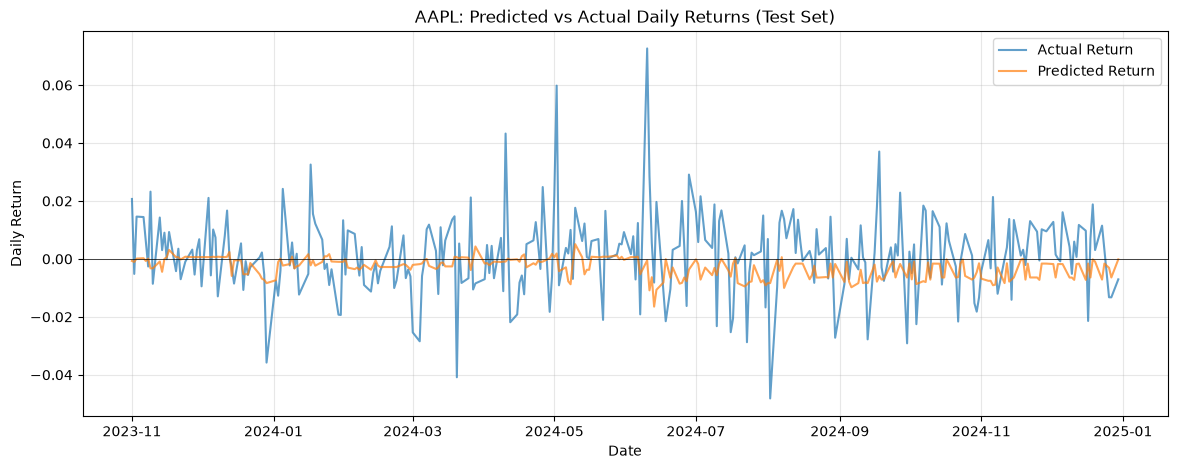

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Actual Return', alpha=0.7)
plt.plot(y_test.index, y_pred, label='Predicted Return', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.5)
plt.title('AAPL: Predicted vs Actual Daily Returns (Test Set)')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Feature Importance

Checking which features the model relied on most, to diagnose whether our engineered
features contain meaningful signal, or whether the model defaulted to minimal reliance
on any single feature (a sign of weak overall signal).

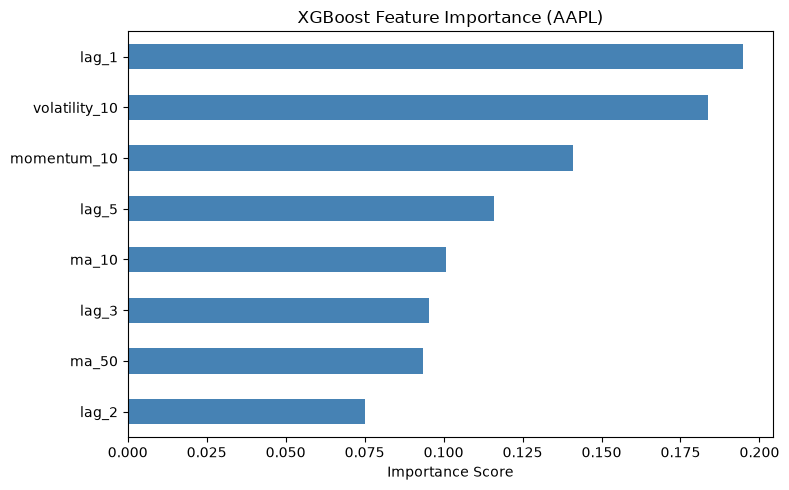

lag_1            0.194656
volatility_10    0.183581
momentum_10      0.140975
lag_5            0.115914
ma_10            0.100899
lag_3            0.095495
ma_50            0.093400
lag_2            0.075081
dtype: float32


In [10]:
# Extract feature importance scores from the trained model
importance = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind='barh', color='steelblue')
plt.title('XGBoost Feature Importance (AAPL)')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importance)

## Findings: 1-Day Return Prediction

The XGBoost model, trained on lagged returns, moving averages, volatility, and momentum
features, did **not** outperform a naive baseline (predicting the historical average return)
on next-day AAPL returns:

- XGBoost RMSE (0.01445) was slightly higher than the naive baseline (0.01368)
- Directional accuracy (46.92%) was below random chance (50%)
- Feature importance was evenly distributed (no single dominant feature), suggesting
  weak individual signal across all engineered features

**Interpretation**: This is consistent with the well-documented difficulty of predicting
single-day stock returns, which are close to a random walk. Rather than over-fit or
cherry-pick a "better-looking" result, this finding is reported honestly. As a next step,
we test whether predicting returns over a longer horizon (5 days) yields more learnable signal.